In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load data
df = pd.read_csv('../binning/mapped_gt.csv')

# Extract features (wavelength columns) and target
wave_cols = [col for col in df.columns if col.replace('.', '').replace('-', '').isdigit() or 
             (col.startswith('wave_') and col[5:].isdigit())]

print(f"Total samples: {len(df)}")
print(f"Unique sample IDs: {df['id'].nunique()}")

# Find IDs with NaN in wave columns
ids_with_nan = df[df[wave_cols].isna().any(axis=1)]['id'].unique()
print(f"IDs with NaN in wave columns: {len(ids_with_nan)}")

# Drop all rows with IDs that have NaN in wave columns
df = df[~df['id'].isin(ids_with_nan)].copy()

print(f"After dropping NaN IDs - Total samples: {len(df)}")
print(f"After dropping NaN IDs - Unique sample IDs: {df['id'].nunique()}")
print(f"Target range: [{df['evoo_conc'].min():.2f}, {df['evoo_conc'].max():.2f}]")


Total samples: 22752
Unique sample IDs: 619
IDs with NaN in wave columns: 8
After dropping NaN IDs - Total samples: 22464
After dropping NaN IDs - Unique sample IDs: 611
Target range: [0.00, 100.00]


In [4]:
# Split by sample IDs (stratified by mean evoo_conc per ID)
# Get unique IDs and their mean target values for stratification
id_stats = df.groupby('id')['evoo_conc'].agg(['mean', 'count']).reset_index()
id_stats.columns = ['id', 'mean_evoo_conc', 'count']

# Create bins for stratification based on mean evoo_conc
n_bins = 10
id_stats['bin'] = pd.cut(id_stats['mean_evoo_conc'], bins=n_bins, labels=False, duplicates='drop')

# First split: train+val IDs vs test IDs
ids_temp, ids_test = train_test_split(
    id_stats['id'].values, 
    test_size=0.2, 
    random_state=42, 
    stratify=id_stats['bin']
)

# Second split: train IDs vs val IDs
id_stats_temp = id_stats[id_stats['id'].isin(ids_temp)]
id_stats_temp['bin'] = pd.cut(id_stats_temp['mean_evoo_conc'], bins=n_bins, labels=False, duplicates='drop')

ids_train, ids_val = train_test_split(
    ids_temp,
    test_size=0.2,
    random_state=42,
    stratify=id_stats_temp['bin']
)

# Filter dataframe by IDs
df_train = df[df['id'].isin(ids_train)].copy()
df_val = df[df['id'].isin(ids_val)].copy()
df_test = df[df['id'].isin(ids_test)].copy()

print(f"Train: {len(df_train)} rows from {len(ids_train)} IDs")
print(f"Val:   {len(df_val)} rows from {len(ids_val)} IDs")
print(f"Test:  {len(df_test)} rows from {len(ids_test)} IDs")

# Extract features and targets
X_train = df_train[wave_cols].values
y_train = df_train['evoo_conc'].values

X_val = df_val[wave_cols].values
y_val = df_val['evoo_conc'].values

X_test = df_test[wave_cols].values
y_test = df_test['evoo_conc'].values

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Verify no NaN remains
print(f"NaN in X_train: {np.isnan(X_train).sum()}")
print(f"NaN in y_train: {np.isnan(y_train).sum()}")
print(f"NaN in X_val: {np.isnan(X_val).sum()}")
print(f"NaN in y_val: {np.isnan(y_val).sum()}")


Train: 14292 rows from 390 IDs
Val:   3600 rows from 98 IDs
Test:  4572 rows from 123 IDs
NaN in X_train: 0
NaN in y_train: 0
NaN in X_val: 0
NaN in y_val: 0


In [5]:
# Dataset class
class SpectraDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create data loaders
train_dataset = SpectraDataset(X_train, y_train)
val_dataset = SpectraDataset(X_val, y_val)
test_dataset = SpectraDataset(X_test, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [6]:
# ResNet-based model for spectra regression
class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features):
        super(ResidualBlock, self).__init__()
        self.linear1 = nn.Linear(in_features, out_features)
        self.ln1 = nn.LayerNorm(out_features)
        self.linear2 = nn.Linear(out_features, out_features)
        self.ln2 = nn.LayerNorm(out_features)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)
        
        # Shortcut connection
        self.shortcut = nn.Linear(in_features, out_features) if in_features != out_features else nn.Identity()
    
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.linear1(x)
        out = self.ln1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.linear2(out)
        out = self.ln2(out)
        out += residual
        out = self.relu(out)
        return out

class ResNetSpectraRegressor(nn.Module):
    def __init__(self, input_dim=204, hidden_dim=256, num_blocks=4, output_dim=1):
        super(ResNetSpectraRegressor, self).__init__()
        
        # Initial projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.ln_input = nn.LayerNorm(hidden_dim)
        self.relu = nn.ReLU()
        
        # Residual blocks
        self.blocks = nn.ModuleList()
        for i in range(num_blocks):
            self.blocks.append(ResidualBlock(hidden_dim, hidden_dim))
        
        # Output layer
        self.output = nn.Linear(hidden_dim, output_dim)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.ln_input(x)
        x = self.relu(x)
        
        for block in self.blocks:
            x = block(x)
        
        x = self.output(x)
        return x.squeeze()

# Model configuration
N_BLOCKS = 10
HIDDEN_DIM = 512
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ResNetSpectraRegressor(input_dim=X_train.shape[1], hidden_dim=HIDDEN_DIM, 
                                num_blocks=N_BLOCKS, output_dim=1).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 5,380,097


In [33]:
# Training setup
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True, min_lr=1e-6)
num_epochs = 100

# Training loop
best_val_loss = float('inf')
for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Check for NaN in input
        if torch.isnan(X_batch).any() or torch.isnan(y_batch).any():
            print("Warning: NaN detected in input data!")
            continue
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        
        # Check for NaN in outputs
        if torch.isnan(outputs).any():
            print("Warning: NaN in model outputs!")
            continue
        
        loss = criterion(outputs, y_batch)
        
        if torch.isnan(loss):
            print("Warning: NaN loss detected!")
            continue
        
        loss.backward()
        
        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            if not torch.isnan(loss):
                val_loss += loss.item()
    
    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    
    # Update learning rate
    scheduler.step(val_loss)

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
    
    # Early stopping if NaN persists
    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f"Stopping early due to NaN at epoch {epoch+1}")
        break


Epoch [1/100], Train Loss: 202.7224, Val Loss: 64.7405
Epoch [10/100], Train Loss: 4.7396, Val Loss: 10.2116
Epoch [20/100], Train Loss: 2.7782, Val Loss: 5.7908
Epoch [30/100], Train Loss: 1.7443, Val Loss: 6.7015
Epoch [40/100], Train Loss: 1.3220, Val Loss: 4.6046
Epoch [50/100], Train Loss: 1.1719, Val Loss: 5.8674
Epoch [60/100], Train Loss: 1.0082, Val Loss: 4.9836
Epoch [70/100], Train Loss: 0.8397, Val Loss: 3.6826
Epoch [80/100], Train Loss: 0.3552, Val Loss: 4.0598
Epoch [90/100], Train Loss: 0.2588, Val Loss: 4.1976
Epoch [100/100], Train Loss: 0.1433, Val Loss: 3.2339


In [34]:
# Evaluation on test set
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        y_pred.extend(outputs.cpu().numpy())
        y_true.extend(y_batch.numpy())

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n" + "="*50)
print("Test Set Results:")
print("="*50)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")
print("="*50)



Test Set Results:
RMSE: 3.0435
MAE:  1.2805
R²:   0.9919


In [7]:
# Hold-out split: evoo_conc == 90 exclusively in test set
# Reload clean data
df_clean = pd.read_csv('../binning/mapped_gt.csv')
wave_cols = [col for col in df_clean.columns if col.replace('.', '').replace('-', '').isdigit() or 
             (col.startswith('wave_') and col[5:].isdigit())]

# Drop IDs with NaN in wave columns
ids_with_nan = df_clean[df_clean[wave_cols].isna().any(axis=1)]['id'].unique()
df_clean = df_clean[~df_clean['id'].isin(ids_with_nan)].copy()

# Split: evoo_conc == 90 goes to test, rest goes to train/val
df_test_holdout = df_clean[df_clean['evoo_conc'] == 90].copy()
df_trainval_holdout = df_clean[df_clean['evoo_conc'] != 90].copy()

print(f"Hold-out split:")
print(f"Test (evoo_conc == 90): {len(df_test_holdout)} rows from {df_test_holdout['id'].nunique()} IDs")
print(f"Train+Val (evoo_conc != 90): {len(df_trainval_holdout)} rows from {df_trainval_holdout['id'].nunique()} IDs")


Hold-out split:
Test (evoo_conc == 90): 864 rows from 23 IDs
Train+Val (evoo_conc != 90): 21600 rows from 588 IDs


In [11]:
# Split trainval by IDs (stratified)
id_stats_holdout = df_trainval_holdout.groupby('id')['evoo_conc'].agg(['mean', 'count']).reset_index()
id_stats_holdout.columns = ['id', 'mean_evoo_conc', 'count']

n_bins = 10
id_stats_holdout['bin'] = pd.cut(id_stats_holdout['mean_evoo_conc'], bins=n_bins, labels=False, duplicates='drop')

ids_train_holdout, ids_val_holdout = train_test_split(
    id_stats_holdout['id'].values,
    test_size=0.2,
    random_state=42,
    stratify=id_stats_holdout['bin']
)

df_train_holdout = df_trainval_holdout[df_trainval_holdout['id'].isin(ids_train_holdout)].copy()
df_val_holdout = df_trainval_holdout[df_trainval_holdout['id'].isin(ids_val_holdout)].copy()

print(f"Train: {len(df_train_holdout)} rows from {len(ids_train_holdout)} IDs")
print(f"Val:   {len(df_val_holdout)} rows from {len(ids_val_holdout)} IDs")
print(f"Test:  {len(df_test_holdout)} rows from {df_test_holdout['id'].nunique()} IDs (evoo_conc == 90 only)")

# Extract features and targets
X_train_holdout = df_train_holdout[wave_cols].values
y_train_holdout = df_train_holdout['evoo_conc'].values

X_val_holdout = df_val_holdout[wave_cols].values
y_val_holdout = df_val_holdout['evoo_conc'].values

X_test_holdout = df_test_holdout[wave_cols].values
y_test_holdout = df_test_holdout['evoo_conc'].values

# Normalize features
scaler_holdout = StandardScaler()
X_train_holdout = scaler_holdout.fit_transform(X_train_holdout)
X_val_holdout = scaler_holdout.transform(X_val_holdout)
X_test_holdout = scaler_holdout.transform(X_test_holdout)


Train: 17316 rows from 470 IDs
Val:   4284 rows from 118 IDs
Test:  864 rows from 23 IDs (evoo_conc == 90 only)


In [12]:
# Create data loaders for hold-out split
train_dataset_holdout = SpectraDataset(X_train_holdout, y_train_holdout)
val_dataset_holdout = SpectraDataset(X_val_holdout, y_val_holdout)
test_dataset_holdout = SpectraDataset(X_test_holdout, y_test_holdout)

train_loader_holdout = DataLoader(train_dataset_holdout, batch_size=64, shuffle=True)
val_loader_holdout = DataLoader(val_dataset_holdout, batch_size=64, shuffle=False)
test_loader_holdout = DataLoader(test_dataset_holdout, batch_size=64, shuffle=False)


In [13]:
# Create new model for hold-out split
model_holdout = ResNetSpectraRegressor(input_dim=X_train_holdout.shape[1], hidden_dim=HIDDEN_DIM, 
                                       num_blocks=N_BLOCKS, output_dim=1).to(device)
print(f"Hold-out model parameters: {sum(p.numel() for p in model_holdout.parameters()):,}")


Hold-out model parameters: 5,380,097


In [20]:
# Training setup
N_BLOCKS = 10
HIDDEN_DIM = 512
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_holdout = ResNetSpectraRegressor(input_dim=X_train_holdout.shape[1], hidden_dim=HIDDEN_DIM, 
                                num_blocks=N_BLOCKS, output_dim=1).to(device)
print(f"Model parameters: {sum(p.numel() for p in model_holdout.parameters()):,}")
criterion_holdout = nn.MSELoss()
optimizer_holdout = optim.Adam(model_holdout.parameters(), lr=0.0001, weight_decay=5e-6)
scheduler_holdout = optim.lr_scheduler.ReduceLROnPlateau(optimizer_holdout, mode='min', factor=0.5, patience=10, verbose=True, min_lr=1e-6)
num_epochs_holdout = 100
best_model_holdout = model_holdout

# Training loop
best_val_loss_holdout = float('inf')
for epoch in range(num_epochs_holdout):
    # Training
    model_holdout.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader_holdout:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        if torch.isnan(X_batch).any() or torch.isnan(y_batch).any():
            continue
        
        optimizer_holdout.zero_grad()
        outputs = model_holdout(X_batch)
        
        if torch.isnan(outputs).any():
            continue
        
        loss = criterion_holdout(outputs, y_batch)
        
        if torch.isnan(loss):
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_holdout.parameters(), max_norm=1.0)
        optimizer_holdout.step()
        
        train_loss += loss.item()
    
    # Validation
    model_holdout.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_holdout:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_holdout(X_batch)
            loss = criterion_holdout(outputs, y_batch)
            if not torch.isnan(loss):
                val_loss += loss.item()
    
    train_loss /= len(train_loader_holdout)
    val_loss /= len(val_loader_holdout)
    
    scheduler_holdout.step(val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_holdout}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss_holdout:
        best_val_loss_holdout = val_loss
        best_model_holdout = model_holdout
    
    if np.isnan(train_loss) or np.isnan(val_loss):
        print(f"Stopping early due to NaN at epoch {epoch+1}")
        break

Model parameters: 5,380,097
Epoch [1/100], Train Loss: 177.0918, Val Loss: 35.9293
Epoch [10/100], Train Loss: 4.3183, Val Loss: 10.3197
Epoch [20/100], Train Loss: 2.3147, Val Loss: 7.2912
Epoch [30/100], Train Loss: 1.5162, Val Loss: 7.9564
Epoch [40/100], Train Loss: 1.1168, Val Loss: 5.0434
Epoch [50/100], Train Loss: 0.4768, Val Loss: 4.4806
Epoch [60/100], Train Loss: 0.3385, Val Loss: 4.8087
Epoch [70/100], Train Loss: 0.3139, Val Loss: 4.3382
Epoch [80/100], Train Loss: 0.1509, Val Loss: 4.6486
Epoch [90/100], Train Loss: 0.1048, Val Loss: 4.4949
Epoch [100/100], Train Loss: 0.0810, Val Loss: 4.3089


In [39]:
model_holdout = best_model_holdout
model_holdout.eval()
y_pred_holdout = []
y_true_holdout = []

with torch.no_grad():
    for X_batch, y_batch in val_loader_holdout:
        X_batch = X_batch.to(device)
        outputs = model_holdout(X_batch)
        y_pred_holdout.extend(outputs.cpu().numpy())
        y_true_holdout.extend(y_batch.numpy())

y_pred_holdout = np.array(y_pred_holdout)
y_true_holdout = np.array(y_true_holdout)

# Calculate metrics
rmse_holdout = np.sqrt(mean_squared_error(y_true_holdout, y_pred_holdout))
mae_holdout = mean_absolute_error(y_true_holdout, y_pred_holdout)
r2_holdout = r2_score(y_true_holdout, y_pred_holdout)

print("\n" + "="*50)
print("Hold-out Test Set Results (evoo_conc == 90 only):")
print("="*50)
print(f"RMSE: {rmse_holdout:.4f}")
print(f"MAE:  {mae_holdout:.4f}")
print(f"R²:   {r2_holdout:.4f}")
print(f"True values range: [{y_true_holdout.min():.2f}, {y_true_holdout.max():.2f}]")
print(f"Predicted values range: [{y_pred_holdout.min():.2f}, {y_pred_holdout.max():.2f}]")
print("="*50)


Hold-out Test Set Results (evoo_conc == 90 only):
RMSE: 2.0768
MAE:  0.9434
R²:   0.9963
True values range: [0.00, 100.00]
Predicted values range: [-0.17, 101.15]


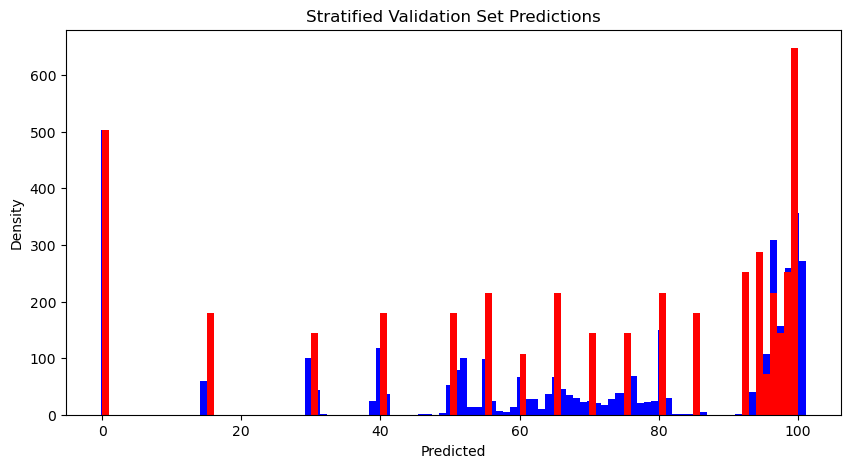

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(y_pred_holdout, bins = 100, color='blue')
plt.hist(y_true_holdout, bins = 100, color='red')
plt.xlabel('Predicted')
plt.ylabel('Density')
plt.title('Stratified Validation Set Predictions')
plt.show()

In [37]:
# Evaluation on hold-out test set (evoo_conc == 90 only)
model_holdout = best_model_holdout
model_holdout.eval()
y_pred_holdout = []
y_true_holdout = []


with torch.no_grad():
    for X_batch, y_batch in test_loader_holdout:
        X_batch = X_batch.to(device)
        outputs = model_holdout(X_batch)
        y_pred_holdout.extend(outputs.cpu().numpy())
        y_true_holdout.extend(y_batch.numpy())

y_pred_holdout = np.array(y_pred_holdout)
y_true_holdout = np.array(y_true_holdout)

# Calculate metrics
rmse_holdout = np.sqrt(mean_squared_error(y_true_holdout, y_pred_holdout))
mae_holdout = mean_absolute_error(y_true_holdout, y_pred_holdout)
r2_holdout = r2_score(y_true_holdout, y_pred_holdout)

print("\n" + "="*50)
print("Hold-out Test Set Results (evoo_conc == 90 only):")
print("="*50)
print(f"RMSE: {rmse_holdout:.4f}")
print(f"MAE:  {mae_holdout:.4f}")
print(f"R²:   {r2_holdout:.4f}")
print(f"True values range: [{y_true_holdout.min():.2f}, {y_true_holdout.max():.2f}]")
print(f"Predicted values range: [{y_pred_holdout.min():.2f}, {y_pred_holdout.max():.2f}]")
print("="*50)



Hold-out Test Set Results (evoo_conc == 90 only):
RMSE: 5.8355
MAE:  5.4556
R²:   0.0000
True values range: [90.00, 90.00]
Predicted values range: [77.46, 99.99]


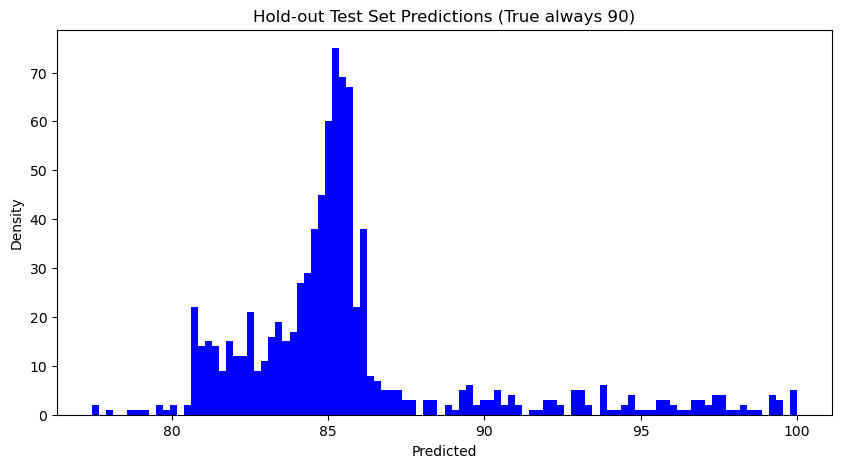

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(y_pred_holdout, bins = 100, color='blue')
plt.xlabel('Predicted')
plt.ylabel('Density')
plt.title('Hold-out Test Set Predictions (True always 90)')
plt.show()